# Deparking analysis
We have experienced that the current deparking code leads to extremely high parking costs. The notebook aims to analyze why this is the case. We ran the simulation 10 iterations on the math cluster and will analyze it now.

In [15]:
import pandas as pd

%config InlineBackend.figure_format = "retina"

occupancy_9 = pd.read_csv("../../../../output/deparking-debug/ITERS/it.9/berlin-v6.4.9.parking_occupancy.csv.zst")
costs_10 = pd.read_csv("../../../../output/deparking-debug/ITERS/it.10/berlin-v6.4.10.parking_costs.csv.zst")

In [16]:
occupancy_9

,linkId,from_time,to_time,length,occupancy,initial
0,-245859006,0.0,54039.0,178.04,0.0,0.0
1,-245859006,54039.0,69067.0,178.04,1.0,0.0
2,-245859006,69067.0,inf,178.04,0.0,0.0
3,-218722226,0.0,40231.0,851.81,0.0,0.0
4,-218722226,40231.0,42597.0,851.81,1.0,0.0
...,...,...,...,...,...,...
126909,-25814594#0,57060.0,78456.0,190.92,1.0,0.0
126910,-25814594#0,78456.0,inf,190.92,0.0,0.0
126911,-1125022715,0.0,37462.0,442.76,0.0,0.0
126912,-1125022715,37462.0,39379.0,442.76,1.0,0.0


In [20]:
costs_10

,linkId,from_time,to_time,cost,spots_available
0,-1002247009,0,7200,5722.045898,1.00000
1,-1002247009,7200,14400,5722.045898,1.00000
2,-1002247009,14400,21600,5722.045898,1.00000
3,-1002247009,21600,28800,5722.045898,1.00000
4,-1002247009,28800,36000,5722.045898,1.00000
...,...,...,...,...,...
21030,986163882#1,108000,115200,34.171875,1.00000
21031,986163882#1,115200,122400,34.171875,1.00000
21032,986163882#1,122400,129600,34.171875,1.00000
21033,993808310#0,36000,43200,1.250984,0.28728


<Axes: xlabel='spots_available', ylabel='cost'>

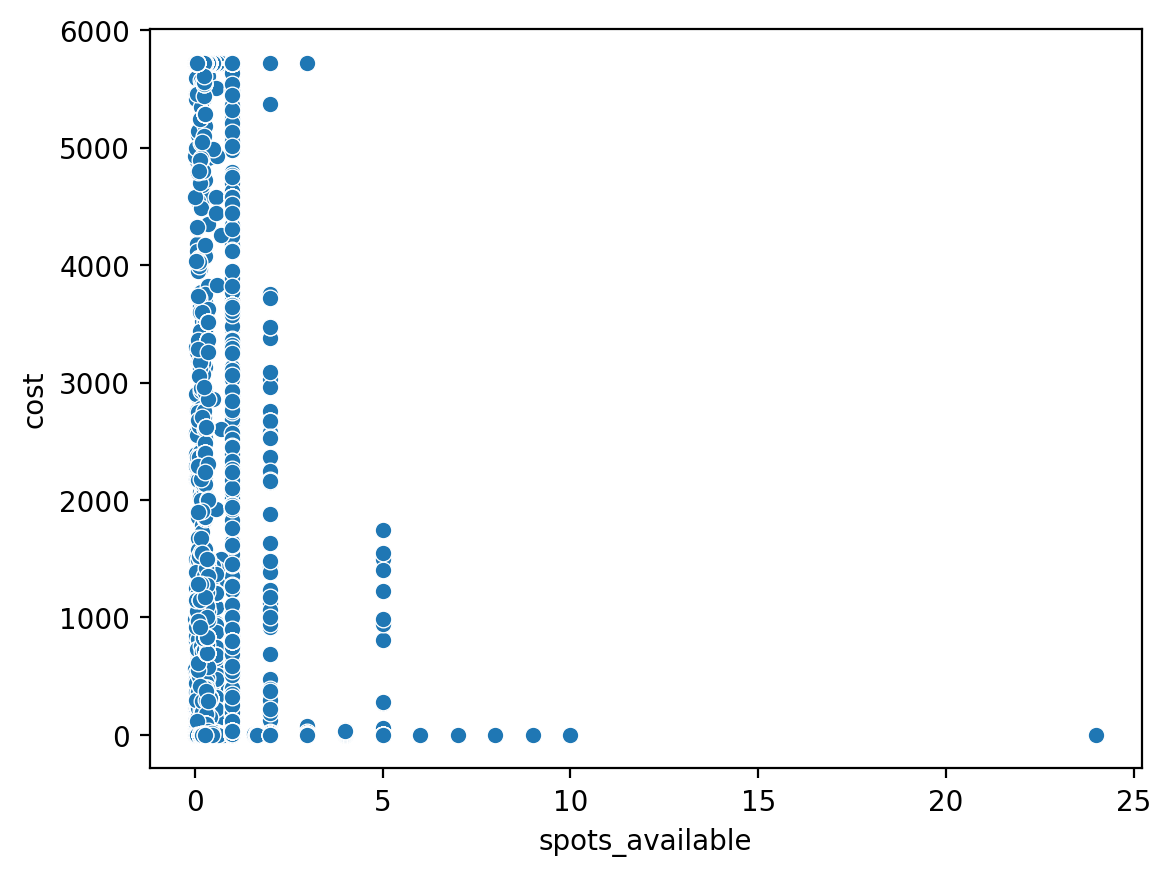

In [21]:
# plot scatterplot of costs_10: x = spots_available, y = cost with seaborn
import seaborn as sns
sns.scatterplot(data=costs_10, x="spots_available", y="cost")

have a look at some exemplary link that has high parking cost: 37289167#2 --> there was a bug in the implementation with the multimodallinkchooser. lets see, if this link still has problems afterwards.

investigate other link (-10149019#2) outside of zone

In [26]:
link = "429447291"
occupancy_9[occupancy_9["linkId"]==link]

,linkId,from_time,to_time,length,occupancy,initial
208,429447291,0.0,44204.0,150.73,0.0,0.0
209,429447291,44204.0,82076.0,150.73,1.0,0.0
210,429447291,82076.0,inf,150.73,0.0,0.0


In [27]:
costs_10[costs_10["linkId"]==link]

,linkId,from_time,to_time,cost,spots_available
18841,429447291,43200,50400,5549.277002,0.200973
18842,429447291,50400,57600,5722.045898,0.200973
18843,429447291,57600,64800,5722.045898,0.200973
18844,429447291,64800,72000,5722.045898,0.200973
18845,429447291,72000,79200,5722.045898,0.200973
18846,429447291,79200,86400,25.364079,0.200973
